# 01 — Initial Data Analysis

**Project:** Dynamic Rental Price Prediction through Multi-Platform Data Scraping, EDA, Ensemble ML & Explainable AI

**Purpose:** Load a raw rental dataset from `data/raw/`, inspect its structure, and produce a preliminary profile (shape, columns, types, missing values, statistics, and basic price distribution).

> **Note:** This notebook uses **real data only**. No synthetic or fake data is generated. If no data file is found in `data/raw/`, a graceful message is shown instead.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

RAW_DIR = Path("../data/raw")
print(f"Looking for data files in: {RAW_DIR.resolve()}")

Looking for data files in: C:\Users\aayus\OneDrive\Documents\Major Project\rental-price-prediction-xai\data\raw


## 1 — Locate and Load the Dataset

In [2]:
# Support both .csv and .csv.gz files
data_files = sorted(
    list(RAW_DIR.glob("*.csv")) + list(RAW_DIR.glob("*.csv.gz"))
)

if not data_files:
    print(
        "\u26a0\ufe0f  No CSV file found in data/raw/.\n"
        "   Place your rental dataset (e.g. rentals.csv or rentals.csv.gz) in that folder and re-run this cell."
    )
    df = None
else:
    data_path = data_files[0]
    print(f"Loading: {data_path.name}")
    df = pd.read_csv(data_path)
    print(f"\u2705 Loaded {len(df):,} rows \u00d7 {df.shape[1]} columns")

Loading: new_york_listings.csv.gz
✅ Loaded 490 rows × 90 columns


## 2 — Quick Inspection

If no data was loaded, the cells below will print a placeholder message and skip analysis.

In [3]:
if df is not None:
    print(f"Shape: {df.shape}")
    print(f"\nColumn names ({len(df.columns)}):")
    for col in df.columns:
        print(f"  - {col}")
else:
    print("Skipped -- no data loaded.")

Shape: (490, 90)

Column names (90):
  - id
  - listing_url
  - scrape_id
  - last_scraped
  - source
  - name
  - description
  - neighborhood_overview
  - picture_url
  - host_id
  - host_url
  - host_profile_id
  - host_profile_url
  - host_name
  - host_since
  - hosts_time_as_user_years
  - hosts_time_as_user_months
  - hosts_time_as_host_years
  - hosts_time_as_host_months
  - host_location
  - host_about
  - host_response_time
  - host_response_rate
  - host_acceptance_rate
  - host_is_superhost
  - host_thumbnail_url
  - host_picture_url
  - host_neighbourhood
  - host_listings_count
  - host_total_listings_count
  - host_verifications
  - host_has_profile_pic
  - host_identity_verified
  - neighbourhood
  - neighbourhood_cleansed
  - neighbourhood_group_cleansed
  - latitude
  - longitude
  - property_type
  - room_type
  - accommodates
  - bathrooms
  - bathrooms_text
  - bedrooms
  - beds
  - amenities
  - price
  - price_quote_checkin_date
  - price_quote_checkout_date
  - 

In [4]:
if df is not None:
    print("First 5 rows:")
    display(df.head())

First 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,1462661762635155041,https://www.airbnb.com/users/profile/146266176...,Kenneth,NaN,13,5,13,4,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,NaN,NaN,t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Kitchen"", ""Essentials"", ""Heating"", ""Wifi"", ""...",$80.43,2027-03-31,2027-04-28,2252.0,80.43,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",28.0,1125.0,28.0,28.0,1125.0,1125.0,28.0,1125.0,NaN,t,0,0,0,77,2026-06-16,9,0,0,0,0,0,0.0,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,1463087024016718788,https://www.airbnb.com/users/profile/146308702...,Ming,NaN,11,10,11,10,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Free washer \u2013 In unit"", ""Microwave"", ""S...",$211.00,2026-07-20,2026-07-21,211.0,211.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,1125.0,1.0,3.0,1125.0,1125.0,2.7,1125.0,NaN,t,0,23,53,328,2026-06-16,317,8,0,162,9,48,10128.0,2014-08-15,2026-01-25,4.75,4.88,4.87,4.85,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.20
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,https://www.airbnb.com/users/show/29288920,1465431505328745177,https://www.airbnb.com/users/profile/146543150...,Gregg,NaN,11,3,11,3,"Albany, NY",I am an Albany native .I have lived in Ireland...,NaN,NaN,NaN,f

In [5]:
if df is not None:
    print("Last 5 rows:")
    display(df.tail())

Last 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
485,1681915932025735153,https://www.airbnb.com/rooms/1681915932025735153,20260616211424,2026-06-16,city scrape,Perfect Albany Getaway Near Hospitals & Downtown,Stylish downtown Albany apartment unit near be...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,512736975,https://www.airbnb.com/users/show/512736975,1470305963298869838,https://www.airbnb.com/users/profile/147030596...,Miguelino,NaN,3,1,3,1,"New York, NY",I'm Miguelino and I love to travel and archite...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/bcb1c...,NaN,2,NaN,NaN,t,t,NaN,TENTH WARD,NaN,42.660960,-73.775850,Entire rental unit,Entire home/apt,4,1.0,1 bath,1.0,2.0,"[""Shower gel"", ""TV"", ""Wifi"", ""Smoke alarm"", ""F...",$149.00,2026-09-01,2026-09-02,149.00,149.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,365.0,1.0,2.0,365.0,365.0,1.3,365.0,NaN,t,0,0,13,193,2026-06-16,0,0,0,122,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
486,1689544536474585971,https://www.airbnb.com/rooms/1689544536474585971,20260616211424,2026-06-16,city scrape,Great spot in Albany,"This special place is close to everything, mak...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3073250,https://www.airbnb.com/users/show/3073250,1462617669326761032,https://www.airbnb.com/users/profile/146261766...,Dan,NaN,13,10,10,10,"Montreal, Canada","Hi !\nI Work in Graphics industry, and film po...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User-...,NaN,11,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.651231,-73.762446,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Free parking on premises"", ""Pets ...",$213.00,2026-08-01,2026-08-02,213.00,213.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,365.0,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,0,14,44,319,2026-06-16,0,0,0,153,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
487,1697861560802480129,https://www.airbnb.com/rooms/1697861560802480129,20260616211424,2026-06-16,city scrape,AMC Cozy Bedroom,Located in the heart of Albany. The room offer...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,522436003,https://www.airbnb.com/users/show/522436003,1470350667412351703,https://www.airbnb.com/users/profile/147035066...,Adriana,NaN,2,11,2,1,NaN,NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/P

In [6]:
if df is not None:
    df.info()

<class 'pandas.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            490 non-null    int64  
 1   listing_url                                   490 non-null    str    
 2   scrape_id                                     490 non-null    int64  
 3   last_scraped                                  490 non-null    str    
 4   source                                        490 non-null    str    
 5   name                                          490 non-null    str    
 6   description                                   481 non-null    str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   490 non-null    str    
 9   host_id                                       490 non-null    int64  
 10  h

## 3 — Data Types & Missing Values

In [7]:
if df is not None:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    dtype_info = df.dtypes

    summary = pd.DataFrame({
        "dtype": dtype_info,
        "missing_count": missing,
        "missing_pct": missing_pct,
    })
    display(summary)
else:
    print("Skipped -- no data loaded.")

,dtype,missing_count,missing_pct
id,int64,0,0.00
listing_url,str,0,0.00
scrape_id,int64,0,0.00
last_scraped,str,0,0.00
source,str,0,0.00
...,...,...,...
calculated_host_listings_count,int64,0,0.00
calculated_host_listings_count_entire_homes,int64,0,0.00
calculated_host_listings_count_private_rooms,int64,0,0.00
calculated_host_listings_count_shared_rooms,int64,0,0.00


## 4 — Descriptive Statistics

In [8]:
if df is not None:
    print("Numeric columns:")
    display(df.describe().T)
else:
    print("Skipped -- no data loaded.")

Numeric columns:


,count,mean,std,min,25%,50%,75%,max
id,490.0,9.617549e+17,5.800837e+17,2.992450e+06,6.904915e+17,1.112067e+18,1.458295e+18,1.701483e+18
scrape_id,490.0,2.026062e+13,0.000000e+00,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,490.0,6.840569e+15,1.069623e+17,6.490680e+05,4.762598e+07,2.329679e+08,4.667901e+08,1.676923e+18
host_profile_id,490.0,1.472998e+18,2.819249e+16,1.462518e+18,1.463574e+18,1.468232e+18,1.469754e+18,1.676923e+18
...,...,...,...,...,...,...,...,...
calculated_host_listings_count,490.0,7.738776e+00,7.717211e+00,1.000000e+00,2.000000e+00,5.000000e+00,1.100000e+01,2.900000e+01
calculated_host_listings_count_entire_homes,490.0,5.469388e+00,7.478126e+00,0.000000e+00,1.000000e+00,2.000000e+00,7.000000e+00,2.900000e+01
calculated_host_listings_count_private_rooms,490.0,2.124490e+00,4.296145e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.700000e+01
calculated_host_listings_count_shared_rooms,490.0,1.224490e-02,1.100895e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [9]:
if df is not None:
    # pandas 3.x uses StringDtype; include both 'object' and 'string'
    cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    if cat_cols:
        print(f"Categorical / string columns ({len(cat_cols)}):")
        display(df[cat_cols].describe())
    else:
        print("No categorical (object/string) columns found.")

Categorical / string columns (28):


,listing_url,last_scraped,source,name,description,picture_url,host_url,host_profile_url,host_name,host_location,host_about,host_is_superhost,host_picture_url,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_raw,has_availability,calendar_last_scraped,first_review,last_review
count,490,490,490,490,481,490,490,490,490,348,260,490,490,490,490,490,490,490,486,490,458,468,468,468,485,490,430,430
unique,490,2,2,489,420,482,186,186,169,31,95,2,183,2,2,15,21,4,18,474,322,88,107,448,1,2,371,196
top,https://www.airbnb.com/rooms/2992450,2026-06-16,city scrape,Large Bedroom in the heart of downtown Albany.,Welcome to your cozy Albany retreat! Enjoy a c...,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/466790114,https://www.airbnb.com/users/profile/146811396...,⁨Premier Stay Co.⁩,"Albany, NY",Hi my name is Scott Guadagnino. I’ve been in t...,f,https://a0.muscache.com/im/pictures/user/User/...,t,t,SIXTH WARD,Entire rental unit,Entire home/apt,1 bath,"[""Microwave"", ""Waterfront"", ""42 inch TV with p...",$97.00,2026-06-16,2026-06-17,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",t,2026-06-16,2026-02-15,2026-05-17
freq,1,456,456,2,13,4,29,29,29,224,21,275,29,466,488,117,255,345,295,8,7,86,63,4,485,456,5,26


## 5 — Basic Price Analysis

Auto-detect the most likely price/rent column, clean it (strip `$` and `,`), and plot its distribution.

In [10]:
def detect_price_column(dataframe: pd.DataFrame) -> str | None:
    """Heuristic to find the rental price column."""
    candidates = ["rent", "price", "rental_price", "monthly_rent", "Rent", "Price"]
    for name in candidates:
        if name in dataframe.columns:
            return name
    # fallback: first column whose name contains 'rent' or 'price'
    for col in dataframe.columns:
        if any(kw in col.lower() for kw in ("rent", "price")):
            return col
    return None


def parse_price_column(series: pd.Series) -> pd.Series:
    """Convert a price column with $ signs and commas to float."""
    if series.dtype in ("object", "string", "str"):
        cleaned = series.astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
        return pd.to_numeric(cleaned, errors="coerce")
    return series.copy()


price_col = detect_price_column(df) if df is not None else None

if price_col and df is not None:
    print(f"Detected price column: '{price_col}'")
    print(f"Original dtype: {df[price_col].dtype}")
    print(f"Sample values (raw): {df[price_col].head(5).tolist()}")

    # Parse to numeric
    df[price_col] = parse_price_column(df[price_col])
    print(f"\nAfter cleaning -> dtype: {df[price_col].dtype}")
    nulls_after = df[price_col].isnull().sum()
    print(f"NaN values after parsing: {nulls_after}")
    print(f"\nPrice statistics:")
    print(df[price_col].describe())
elif df is not None:
    print(
        "Could not auto-detect a price/rent column.\n"
        "Set `price_col = 'your_column_name'` manually and re-run."
    )
else:
    print("Skipped -- no data loaded.")

Detected price column: 'price'
Original dtype: str
Sample values (raw): ['$80.43', '$211.00', '$97.00', '$160.00', '$86.00']

After cleaning -> dtype: float64
NaN values after parsing: 32

Price statistics:
count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price, dtype: float64


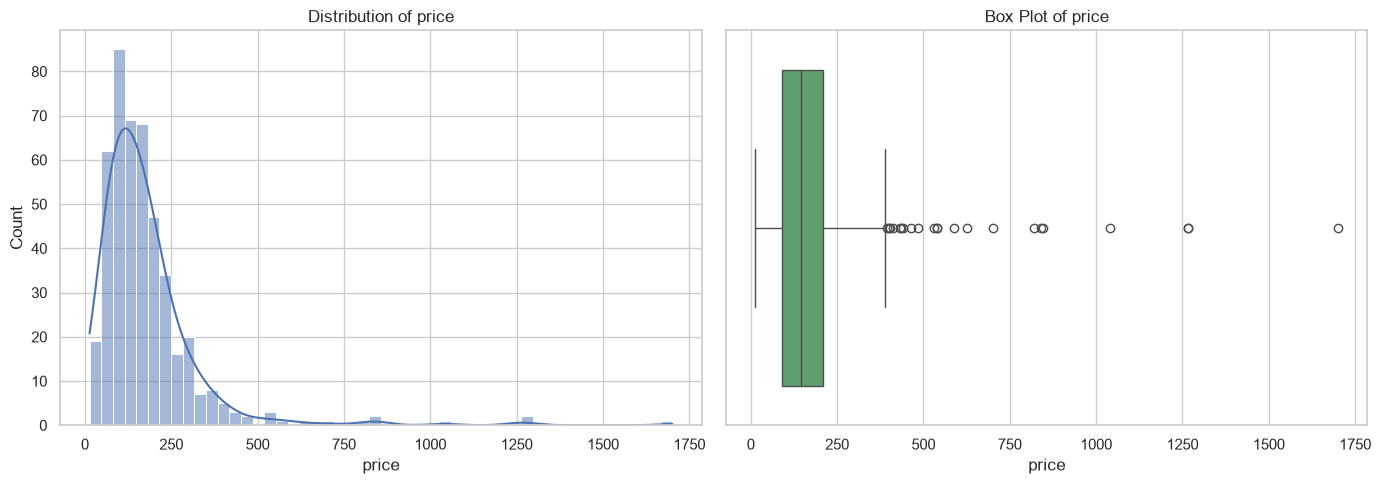

In [11]:
if price_col and df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(df[price_col].dropna(), kde=True, bins=50, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Distribution of {price_col}")
    axes[0].set_xlabel(price_col)
    axes[0].set_ylabel("Count")

    # Box plot
    sns.boxplot(x=df[price_col].dropna(), ax=axes[1], color="#55A868")
    axes[1].set_title(f"Box Plot of {price_col}")
    axes[1].set_xlabel(price_col)

    plt.tight_layout()
    plt.show()
else:
    print("Price visualisation skipped.")

## 6 — Correlation Heatmap (Numeric Columns)

For wide datasets (many numeric columns), we select the top columns most correlated with price to keep the heatmap readable.

Showing top 15 features most correlated with 'price'


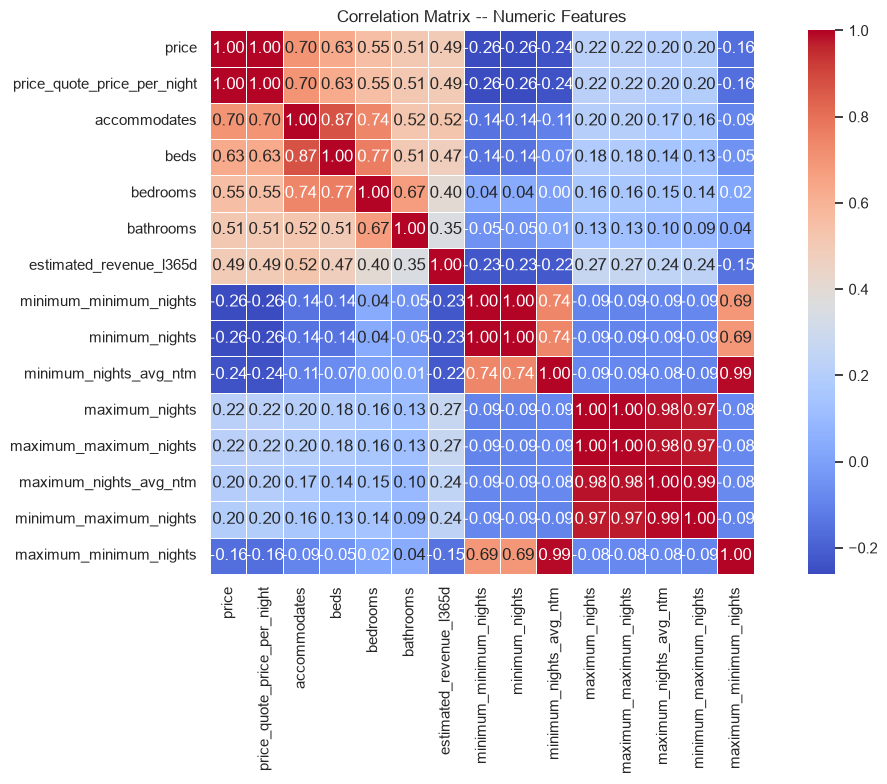

In [12]:
if df is not None:
    num_df = df.select_dtypes(include="number")
    if num_df.shape[1] >= 2:
        # If too many numeric columns, select top 15 most correlated with price
        MAX_COLS = 15
        if num_df.shape[1] > MAX_COLS and price_col and price_col in num_df.columns:
            top_corr = (
                num_df.corr()[price_col]
                .abs()
                .sort_values(ascending=False)
                .head(MAX_COLS)
                .index.tolist()
            )
            num_df = num_df[top_corr]
            print(f"Showing top {MAX_COLS} features most correlated with '{price_col}'")

        plt.figure(figsize=(12, 8))
        sns.heatmap(
            num_df.corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            square=True,
            linewidths=0.5,
        )
        plt.title("Correlation Matrix -- Numeric Features")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough numeric columns for a correlation matrix.")
else:
    print("Skipped -- no data loaded.")

---

## Summary

| Check | Status |
|-------|--------|
| Dataset loaded | Done |
| Shape inspected | Done |
| Missing values reported | Done |
| Descriptive statistics | Done |
| Price distribution plotted | Done |
| Correlation heatmap | Done |

**Next:** Proceed to `02_eda.ipynb` for deeper exploratory analysis.